# Imports and load data

In [111]:
import numpy as np
import pandas as pd
import seaborn as sns 
from pathlib import Path

import matplotlib.pyplot as plt 
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec  

In [112]:
SUBSAMPLED_TESTF1_PATH  = Path("../results/testf1_subsampling.csv")
FULL_TESTF1_PATH  = Path("../results/testf1_full.csv")
REL_F1_PATH  = Path("../results/rel_f1_all.csv")

df = pd.read_csv(SUBSAMPLED_TESTF1_PATH)
df_full = pd.read_csv(FULL_TESTF1_PATH)
df_rel = pd.read_csv(REL_F1_PATH, index_col=0)  

In [113]:
df_rel.index

Index(['randS   \n 100', '200', '400', 'sortS   \n 100', '200', '400',
       'clusS   \n 100', '200', '400'],
      dtype='str')

# Data processing, definitions and plotting Functions

In [114]:
# definitions
df["fam"] = df["fam"].replace("telomerase", "telom.")
df_full["fam"] = df_full["fam"].replace("telomerase", "telom.")

fams = ['5s', 'tRNA',  'tmRNA',   'RNaseP', 'srp',  'telom.', 'grp1', '23s', '16s']
fam_map = {f: i for i, f in enumerate(fams)}
models = df["model"].unique()  
 
PALETTE = {100: "#1B9E77", 200: "#D95F02", 400: "#7570B3"}
MARKERS = {"randS": "o", "sortS": "^", "clusS": "*"}

sns.set_style("whitegrid")

In [134]:
# functions

# plot strategies
def strip(ax, df, fam_map):  
    delta = 0.25
    ds = 3*delta / len(df.groupby("strategy")) if len(df.groupby("strategy")) != 0 else 0  
    x = df["fam"].map(fam_map) - delta 
    # plot
    for strategy, g in df.groupby("strategy"):
        ax.scatter(
            x[g.index],
            g["test_f1"],
            marker=MARKERS[strategy],
            c=[PALETTE[u] for u in g["K"]],
            edgecolors="k",
            lw=0.5,
            s=10,
            alpha=0.75,
            label=strategy,
        )
        x += ds  # move x to the next strategy 


# plot f1 scores for a given model
def plot_f1(ax, df, model, fam_map):
  sns.barplot(
        data=df_full[df_full["model"] == model],
        x="fam",
        y="test_f1",
        order=fams,
        color="gray",
        alpha=0.4,
        errorbar=None,
        ax=ax,
    )
  strip(ax, df[df["model"] == model], fam_map)

  ax.set_ylim(0, 0.95)
  ax.set_title(model, fontsize=8)
  ax.set_xlabel("")
  ax.set_xticks(range(len(fams)))
  ax.set_xticklabels(fams, fontsize=6, rotation=30)
  ax.tick_params(axis="y",  labelsize=7,)
  if ax.get_legend():
      ax.get_legend().remove()

def plot_heatmap(ax, df_rel):
    sns.heatmap(
        df_rel,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        linewidths=0.5,
        cbar=False,
        vmin=0.95,
        vmax=1.25,
        ax=ax,
        annot_kws={"size": 5},
    )

    # Explicit tick positions at cell centers
    ax.set_xticks(np.arange(df_rel.shape[1]) + 0.5)
    ax.set_yticks(np.arange(df_rel.shape[0]) + 0.5)

    ax.set_xticklabels( df_rel.columns, fontsize=5.5,rotation=0, ha="center")

    ax.set_yticklabels( df_rel.index, fontsize=5.5, va="center")

    ax.set_title("Relative F1 vs Baseline", fontsize=8, pad=5)
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(
        axis="both",
        length=0,
        pad=2,
    )

In [135]:
# build the complete figure with all models and the heatmap
def plot_all_models(df, df_rel, save=False):
 
    # set plot size and layout
    fig = plt.figure(figsize=(6.5, 4.4))
    gs = gridspec.GridSpec(2, 4, figure=fig, 
                        width_ratios=[1, 1, 0.15, 1], 
                        wspace=0.05,                  
                        hspace=0.5)                   
    plot_coords = [
        (0, 0), (0, 1), (0, 3), # Row 0: Mod0, Mod1, --, Mod2
        (1, 0), (1, 1)          # Row 1: Mod3, Mod4, --, (Heatmap in 1,3)
    ]

    # 1. plot F1 scores 
    first_ax = None
    for i, model in enumerate(models):
        row, col = plot_coords[i]
        ax = fig.add_subplot(gs[row, col], sharey=first_ax)

        first_ax = first_ax or ax # share y-axis for all subplots

        ax.set_ylabel("F1 Score" if col == 0 else "", fontsize=7)
        ax.tick_params(axis="y", labelleft=(col == 0))
        plot_f1(ax, df, model, fam_map)
    
    # 2. heatmap (1, 3) 
    ax_heat = fig.add_subplot(gs[1, 3]) # Fila 1, Columna 3 (Ultima)
    plot_heatmap(ax_heat, df_rel)
    
    # 3. LEYEND 
    h_baseline = [Patch(color='gray', alpha=0.4, label='Baseline')]
    h_shapes = [Line2D([], [], color='black', marker=marker, linestyle='', markersize=5, label=name) for name, marker in MARKERS.items()]
    h_colors = [Line2D([], [], color=color, marker='D', linestyle='', markersize=5, label=f"{thr}") for thr, color in PALETTE.items()]

    legend_handles = h_baseline + h_shapes + h_colors 
    fig.legend(
        handles=legend_handles,
        loc='lower center', 
        bbox_to_anchor=(0.5, -0.023),
        ncol=7, 
        frameon=False, 
        fontsize=6
    )
    plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.12)
    if save:
        plt.savefig("../figures/4.svg", dpi=300, bbox_inches="tight")
    plt.show()

# Visualize F1 scores

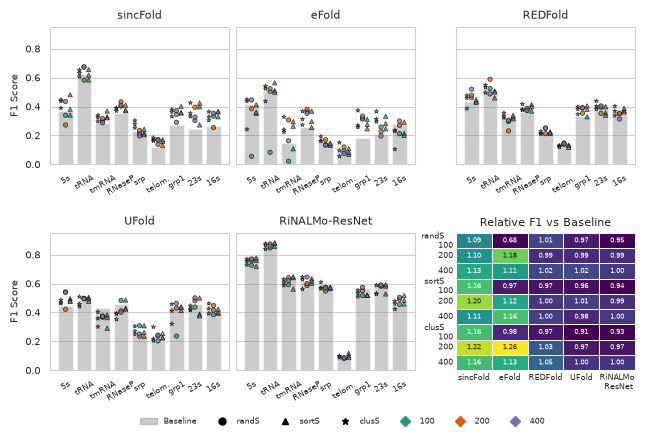

In [136]:
plot_all_models(df, df_rel, save=True)